# 2WikiMultiHopQA — NLP Pipeline
## Çok Adımlı Soru Yanıtlamada Halüsinasyon Analizi

**Pipeline sırası:**
1. Kurulum
2. Veri seti yükleme ve keşif
3. NER (Named Entity Recognition)
4. Dependency Parsing + Soru karmaşıklığı skoru
5. Triple Extraction (OpenIE / REBEL)
6. Sonuçları kaydetme ve görselleştirme

## HÜCRE 1 — Kurulum
Tüm kütüphaneleri yükle. Bu hücre ~3-5 dakika sürer, bir kez çalıştır.

In [ ]:
# Temel kütüphaneler
!pip install -q datasets spacy pandas matplotlib seaborn tqdm

# spaCy İngilizce modeli (NER + dependency parsing için)
!python -m spacy download en_core_web_sm -q

# OpenIE alternatifi olarak rebelllm (triple extraction)
!pip install -q openie

# Transformers (REBEL için)
!pip install -q transformers torch

print('✅ Kurulum tamamlandı!')

## HÜCRE 2 — Kütüphaneleri İçe Aktar

In [2]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import spacy
nlp = spacy.load('en_core_web_sm')

from datasets import load_dataset

print('✅ Kütüphaneler yüklendi!')
print(f'spaCy sürümü: {spacy.__version__}')

✅ Kütüphaneler yüklendi!
spaCy sürümü: 3.8.14


## HÜCRE 3 — Veri Setini Yükle
2WikiMultiHopQA'yı HuggingFace'den indir. İlk seferinde ~500MB indirir, sonra cache'den gelir.

In [ ]:

!pip install -q datasets

from datasets import load_dataset

dataset = load_dataset('framolfese/2WikiMultihopQA', split='train')

print(f'✅ Yüklendi! Toplam: {len(dataset)} soru')
print(f'Sütunlar: {dataset.column_names}')

In [4]:
print(dataset.column_names)
print('\nİlk örnek:')
print(dataset[0])

['id', 'question', 'answer', 'type', 'evidences', 'supporting_facts', 'context']

İlk örnek:
{'id': '13f5ad2c088c11ebbd6fac1f6bf848b6', 'question': 'Are director of film Move (1970 Film) and director of film Méditerranée (1963 Film) from the same country?', 'answer': 'no', 'type': 'bridge_comparison', 'evidences': [['Move (1970 film)', 'director', 'Stuart Rosenberg'], ['Méditerranée (1963 film)', 'director', 'Jean-Daniel Pollet'], ['Stuart Rosenberg', 'country of citizenship', 'American'], ['Jean-Daniel Pollet', 'country of citizenship', 'French']], 'supporting_facts': {'title': ['Move (1970 film)', 'Méditerranée (1963 film)', 'Stuart Rosenberg', 'Jean-Daniel Pollet'], 'sent_id': [0, 0, 0, 0]}, 'context': {'title': ['Stuart Rosenberg', 'Méditerranée (1963 film)', 'Move (1970 film)', 'Ian Barry (director)', 'Peter Levin', 'Brian Johnson (special effects artist)', 'Rachel Feldman', 'Hanro Smitsman', 'Jean-Daniel Pollet', 'Howard W. Koch'], 'sentences': [['Stuart Rosenberg (August 11, 192

## HÜCRE 4 — Veri Setini Keşfet
Soru tiplerini, cevap dağılımını, destekleyen belge sayılarını incele.

Soru tipi dağılımı:
  compositional: 76481 (45.7%)
  comparison: 51963 (31.0%)
  bridge_comparison: 34631 (20.7%)
  inference: 4379 (2.6%)

Ortalama kaynak belge sayısı: 2.00
Min: 2, Max: 2

Ortalama soru uzunluğu: 12.7 kelime


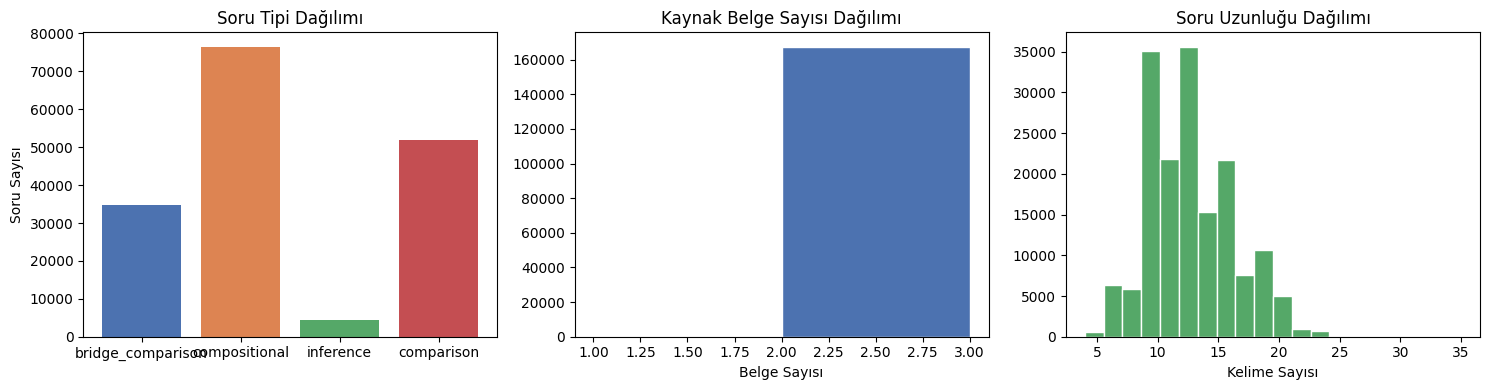

✅ Grafik kaydedildi: veri_seti_analizi.png


In [5]:
# Soru tiplerini say
tipler = Counter([s['type'] for s in dataset])
print('Soru tipi dağılımı:')
for tip, sayi in tipler.most_common():
    print(f'  {tip}: {sayi} ({sayi/len(dataset)*100:.1f}%)')

# Supporting facts sayısını incele (kaç belge gerekiyor?)
belge_sayilari = [len(set([f[0] for f in s['supporting_facts']])) for s in dataset]
print(f'\nOrtalama kaynak belge sayısı: {np.mean(belge_sayilari):.2f}')
print(f'Min: {min(belge_sayilari)}, Max: {max(belge_sayilari)}')

# Soru uzunlukları
soru_uzunluklari = [len(s['question'].split()) for s in dataset]
print(f'\nOrtalama soru uzunluğu: {np.mean(soru_uzunluklari):.1f} kelime')

# Görselleştir
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(tipler.keys(), tipler.values(), color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
axes[0].set_title('Soru Tipi Dağılımı')
axes[0].set_ylabel('Soru Sayısı')

axes[1].hist(belge_sayilari, bins=range(1, max(belge_sayilari)+2), color='#4C72B0', edgecolor='white')
axes[1].set_title('Kaynak Belge Sayısı Dağılımı')
axes[1].set_xlabel('Belge Sayısı')

axes[2].hist(soru_uzunluklari, bins=20, color='#55A868', edgecolor='white')
axes[2].set_title('Soru Uzunluğu Dağılımı')
axes[2].set_xlabel('Kelime Sayısı')

plt.tight_layout()
plt.savefig('veri_seti_analizi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik kaydedildi: veri_seti_analizi.png')

## HÜCRE 5 — Çalışma Altsetini Hazırla
Tüm veri setiyle çalışmak çok uzun sürer. Bridge ve comparison sorularından dengeli bir alt set oluştur.

In [6]:
import random
import pandas as pd
import numpy as np

bridge_sorular = [s for s in dataset if s['type'] in ['bridge', 'bridge_comparison']]
comparison_sorular = [s for s in dataset if s['type'] == 'comparison']

print(f'Bridge soru sayısı: {len(bridge_sorular)}')
print(f'Comparison soru sayısı: {len(comparison_sorular)}')

random.seed(42)
alt_set = random.sample(bridge_sorular, 250) + random.sample(comparison_sorular, 250)
random.shuffle(alt_set)

df = pd.DataFrame({
    'id': [s['id'] for s in alt_set],
    'soru': [s['question'] for s in alt_set],
    'cevap': [s['answer'] for s in alt_set],
    'tip': [s['type'] for s in alt_set],
    'supporting_facts': [s['supporting_facts'] for s in alt_set],
    'context': [s['context'] for s in alt_set],
    'evidences': [s['evidences'] for s in alt_set],
})

# Kaynak belge sayısı — artık dict formatında
df['kaynak_belge_sayisi'] = df['supporting_facts'].apply(
    lambda x: len(set(x['title']))  # liste değil dict, .title ile erişiyoruz
)

print(f'\n✅ Alt set hazır: {df.shape}')
df.head(3)

Bridge soru sayısı: 34631
Comparison soru sayısı: 51963

✅ Alt set hazır: (500, 8)


,id,soru,cevap,tip,supporting_facts,context,evidences,kaynak_belge_sayisi
0,dc7fe05208f511ebbdaaac1f6bf848b6,Does Shaun Berne have the same nationality as ...,no,comparison,"{'title': ['Shaun Berne', 'Michael Riley (curl...","{'title': ['Shaun Berne', 'Michael Riley (film...","[[Shaun Berne, country of citizenship, Austral...",2
1,6ae3a80c08d011ebbd95ac1f6bf848b6,Are both Gabas (River) and San Pedro River (Ch...,no,comparison,"{'title': ['Gabas (river)', 'San Pedro River (...","{'title': ['San Pedro River (Chihuahua)', 'San...","[[Gabas (river), country, France], [San Pedro ...",2
2,08e1eac4086711ebbd5eac1f6bf848b6,Are Airbridge (band) and Dropdead from the sam...,no,comparison,"{'title': ['Dropdead', 'Airbridge (band)'], 's...","{'title': ['June (band)', 'Welcome (band)', 'T...","[[Dropdead, country of origin, American], [Air...",2


## HÜCRE 6 — NER (Named Entity Recognition)
Her sorudaki varlıkları tespit et: kişi adları, yer adları, tarihler, organizasyonlar vs.
Bu, sorunun 'ne kadar çok varlık içerdiğini' ölçmek için kullanılacak.

In [7]:
def ner_analiz(metin):
    """
    Verilen metinden NER çıkarır.
    Döndürür: entity listesi, entity tipi sayıları, toplam entity sayısı
    """
    doc = nlp(metin)

    entities = [(ent.text, ent.label_) for ent in doc.ents]
    entity_tipleri = Counter([ent.label_ for ent in doc.ents])

    return {
        'entities': entities,
        'entity_sayisi': len(entities),
        'benzersiz_entity': len(set([e[0] for e in entities])),
        'kisi_sayisi': entity_tipleri.get('PERSON', 0),
        'yer_sayisi': entity_tipleri.get('GPE', 0) + entity_tipleri.get('LOC', 0),
        'org_sayisi': entity_tipleri.get('ORG', 0),
        'tarih_sayisi': entity_tipleri.get('DATE', 0),
    }

# Test et
test_soru = df['soru'].iloc[0]
print(f'Test sorusu: {test_soru}')
print(f'NER sonucu: {ner_analiz(test_soru)}')

# Tüm soruları işle
print('\nNER analizi yapılıyor...')
ner_sonuclari = [ner_analiz(soru) for soru in tqdm(df['soru'])]

# Sonuçları DataFrame'e ekle
df['ner_entities'] = [r['entities'] for r in ner_sonuclari]
df['entity_sayisi'] = [r['entity_sayisi'] for r in ner_sonuclari]
df['benzersiz_entity'] = [r['benzersiz_entity'] for r in ner_sonuclari]
df['kisi_sayisi'] = [r['kisi_sayisi'] for r in ner_sonuclari]
df['yer_sayisi'] = [r['yer_sayisi'] for r in ner_sonuclari]
df['org_sayisi'] = [r['org_sayisi'] for r in ner_sonuclari]

print('\n✅ NER tamamlandı!')
print(f"Ortalama entity sayısı: {df['entity_sayisi'].mean():.2f}")
print(f"Bridge_comparison sorularında: {df[df['tip']=='bridge_comparison']['entity_sayisi'].mean():.2f}")
print(f"Comparison sorularında: {df[df['tip']=='comparison']['entity_sayisi'].mean():.2f}")

Test sorusu: Does Shaun Berne have the same nationality as Michael Riley (Curler)?
NER sonucu: {'entities': [('Shaun Berne', 'PERSON'), ('Michael Riley', 'PERSON'), ('Curler', 'PERSON')], 'entity_sayisi': 3, 'benzersiz_entity': 3, 'kisi_sayisi': 3, 'yer_sayisi': 0, 'org_sayisi': 0, 'tarih_sayisi': 0}

NER analizi yapılıyor...


100%|██████████| 500/500 [00:03<00:00, 155.64it/s]


✅ NER tamamlandı!
Ortalama entity sayısı: 1.92
Bridge_comparison sorularında: 1.81
Comparison sorularında: 2.02


## HÜCRE 7 — Dependency Parsing + Soru Karmaşıklığı Skoru
Sorunun dilbilgisel yapısını analiz et. Kaç clause var? Kaç fiil var?
Bunları birleştirerek 'karmaşıklık skoru' hesapla.

In [8]:
def karmashklik_analiz(metin):
    """
    Dependency parsing ile soru karmaşıklığını ölç.
    """
    doc = nlp(metin)

    # Kelime sayısı
    kelime_sayisi = len([token for token in doc if not token.is_punct])

    # Fiil sayısı (kaç eylem var?)
    fiil_sayisi = len([token for token in doc if token.pos_ == 'VERB'])

    # Subordinate clause sayısı (bağımlı cümlecik)
    # relcl=relative clause, advcl=adverbial clause, ccomp=clausal complement
    clause_tipleri = ['relcl', 'advcl', 'ccomp', 'xcomp', 'acl']
    clause_sayisi = len([token for token in doc if token.dep_ in clause_tipleri])

    # Soru kelimesi (what, who, where, when, how many...)
    soru_kelimeleri = ['what', 'who', 'where', 'when', 'why', 'how', 'which']
    soru_kelimesi = next(
        (token.text.lower() for token in doc if token.text.lower() in soru_kelimeleri),
        'other'
    )

    # Bağlaç sayısı (and, or, but — çok bağlaç = karmaşık soru)
    baglac_sayisi = len([token for token in doc if token.dep_ == 'cc'])

    # Preposition sayısı (in, of, by, from...)
    edat_sayisi = len([token for token in doc if token.pos_ == 'ADP'])

    # Ağırlıklı karmaşıklık skoru (0-10 arası normalize edilecek)
    # Ağırlıklar: fiil ve clause en önemli
    ham_skor = (
        kelime_sayisi * 0.1 +
        fiil_sayisi * 1.5 +
        clause_sayisi * 2.0 +
        baglac_sayisi * 1.0 +
        edat_sayisi * 0.5
    )

    return {
        'kelime_sayisi': kelime_sayisi,
        'fiil_sayisi': fiil_sayisi,
        'clause_sayisi': clause_sayisi,
        'baglac_sayisi': baglac_sayisi,
        'edat_sayisi': edat_sayisi,
        'soru_kelimesi': soru_kelimesi,
        'ham_karmashklik': ham_skor,
    }

# Test
print(f'Test: {df["soru"].iloc[0]}')
print(karmashklik_analiz(df['soru'].iloc[0]))

# Tüm sorulara uygula
print('\nKarmaşıklık analizi yapılıyor...')
karmashklik_sonuclari = [karmashklik_analiz(soru) for soru in tqdm(df['soru'])]

# DataFrame'e ekle
df['kelime_sayisi'] = [r['kelime_sayisi'] for r in karmashklik_sonuclari]
df['fiil_sayisi'] = [r['fiil_sayisi'] for r in karmashklik_sonuclari]
df['clause_sayisi'] = [r['clause_sayisi'] for r in karmashklik_sonuclari]
df['soru_kelimesi'] = [r['soru_kelimesi'] for r in karmashklik_sonuclari]
df['ham_karmashklik'] = [r['ham_karmashklik'] for r in karmashklik_sonuclari]

# 0-10 arası normalize et
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 10))
df['karmashklik_skoru'] = scaler.fit_transform(df[['ham_karmashklik']]).flatten()

print('\n✅ Karmaşıklık analizi tamamlandı!')
print(f"Ortalama karmaşıklık skoru: {df['karmashklik_skoru'].mean():.2f}/10")
print(f"Bridge_comparison: {df[df['tip']=='bridge_comparison']['karmashklik_skoru'].mean():.2f}")
print(f"Comparison: {df[df['tip']=='comparison']['karmashklik_skoru'].mean():.2f}")

Test: Does Shaun Berne have the same nationality as Michael Riley (Curler)?
{'kelime_sayisi': 11, 'fiil_sayisi': 1, 'clause_sayisi': 0, 'baglac_sayisi': 0, 'edat_sayisi': 1, 'soru_kelimesi': 'other', 'ham_karmashklik': 3.1}

Karmaşıklık analizi yapılıyor...


100%|██████████| 500/500 [00:02<00:00, 169.61it/s]



✅ Karmaşıklık analizi tamamlandı!
Ortalama karmaşıklık skoru: 2.93/10
Bridge_comparison: 3.90
Comparison: 1.97


## HÜCRE 8 — Ara Adım Sayısı Hesapla
Bridge sorularında kaç 'köprü adımı' var? Bu, halüsinasyon analiziyle ilişkilendireceğimiz ana değişken.

In [ ]:
def ara_adim_sayisi_hesapla(supporting_facts):
    kaynak_makaleler = list(set(supporting_facts['title']))
    toplam_fact = len(supporting_facts['title'])

    from collections import Counter
    makale_fact_sayisi = Counter(supporting_facts['title'])

    # Gerçek ara adım sayısı = kaç farklı makaleden
    # kaç cümle kullanılmış (toplam supporting fact cümlesi)
    # Bu, modelin kaç bilgi parçasını birleştirmesi gerektiğini gösterir
    gercek_adim_sayisi = toplam_fact  # Kaç cümle gerekiyor

    return {
        'kaynak_makale_sayisi': len(kaynak_makaleler),
        'kaynak_makaleler': kaynak_makaleler,
        'toplam_fact_sayisi': toplam_fact,
        'gercek_adim_sayisi': gercek_adim_sayisi,  # YENİ
        'maks_fact_tek_makalede': max(makale_fact_sayisi.values()) if makale_fact_sayisi else 0
    }

adim_sonuclari = [
    ara_adim_sayisi_hesapla(row['supporting_facts'])
    for _, row in df.iterrows()
]

# ara_adim_sayisi artık gerçek cümle sayısından geliyor
df['ara_adim_sayisi'] = [r['gercek_adim_sayisi'] for r in adim_sonuclari]
df['toplam_fact_sayisi'] = [r['toplam_fact_sayisi'] for r in adim_sonuclari]

print('Ara adım analizi tamamlandı!')
print(f"\nGerçek ara adım dağılımı:")
print(df['ara_adim_sayisi'].value_counts().sort_index())
print(f"\nSoru tipine göre ortalama adım sayısı:")
print(df.groupby('tip')['ara_adim_sayisi'].mean().round(2))

Ara adım analizi tamamlandı!

Gerçek ara adım dağılımı:
ara_adim_sayisi
2    249
3      1
4    248
5      2
Name: count, dtype: int64

Soru tipine göre ortalama adım sayısı:
tip
bridge_comparison    4.01
comparison           2.00
Name: ara_adim_sayisi, dtype: float64


## HÜCRE 9 — Triple Extraction (REBEL ile)
Her sorudan ve destekleyen belgelerden özne-eylem-nesne üçlüleri çıkar.
REBEL, HuggingFace'de hazır bir relation extraction modelidir.

In [ ]:
def triple_cikart_spacy(metin):
    """
    spaCy dependency parsing ile özne-eylem-nesne üçlüleri çıkarır.
    REBEL'e gerek yok, daha hafif ve stabil çalışır.
    """
    doc = nlp(metin)
    triples = []

    for token in doc:
        # Fiil bul (ana eylem)
        if token.pos_ == 'VERB':
            ozne = None
            nesne = None

            for child in token.children:
                # Özne (nsubj = nominal subject)
                if child.dep_ in ('nsubj', 'nsubjpass'):
                    ozne = ' '.join([t.text for t in child.subtree
                                     if not t.is_punct])

                # Nesne (dobj = direct object, pobj = prepositional object)
                if child.dep_ in ('dobj', 'pobj', 'attr', 'oprd'):
                    nesne = ' '.join([t.text for t in child.subtree
                                      if not t.is_punct])

            if ozne and nesne:
                triples.append({
                    'ozne': ozne.strip(),
                    'iliski': token.lemma_,  # Fiilin kök hali
                    'nesne': nesne.strip()
                })

    return triples

# Test et
test_metin = "Stuart Rosenberg was an American film director who directed Move."
print(f'Test metni: {test_metin}')
print(f'Üçlüler:')
for t in triple_cikart_spacy(test_metin):
    print(f"  ({t['ozne']}) --[{t['iliski']}]--> ({t['nesne']})")

Test metni: Stuart Rosenberg was an American film director who directed Move.
Üçlüler:
  (who) --[direct]--> (Move)


## HÜCRE 10 — Destekleyen Belgelerden Triple Çıkar
Sadece sorudan değil, her sorunun dayandığı Wikipedia paragraflarından da triple çıkar.
Bu triples daha sonra GraphRAG için kullanılacak.

In [11]:
# HÜCRE 10 — Destekleyen belgelerden triple çıkar


from collections import defaultdict

def context_paragraf_al(context, supporting_facts):
    sf_dict = defaultdict(set)
    for makale, cumle_id in zip(supporting_facts['title'], supporting_facts['sent_id']):
        sf_dict[makale].add(cumle_id)

    paragraflar = []
    for makale_adi, cumleler in zip(context['title'], context['sentences']):
        if makale_adi in sf_dict:
            secili_cumleler = [
                cumleler[i] for i in sf_dict[makale_adi]
                if i < len(cumleler)
            ]
            if secili_cumleler:
                paragraflar.append(f"{makale_adi}: {' '.join(secili_cumleler)}")

    return ' | '.join(paragraflar)

# İlk 100 soru için triple çıkar
print('Triple extraction yapılıyor (ilk 100 soru)...')

triple_sonuclari = []

for i, row in tqdm(df.head(100).iterrows(), total=100):
    paragraf = context_paragraf_al(row['context'], row['supporting_facts'])
    triples = triple_cikart_spacy(paragraf)

    triple_sonuclari.append({
        'id': row['id'],
        'triples': triples,
        'triple_sayisi': len(triples),
    })

# DataFrame'e ekle
df.loc[df.index[:100], 'triple_sayisi'] = [r['triple_sayisi'] for r in triple_sonuclari]

print(f'\n✅ Triple extraction tamamlandı!')
print(f"Ortalama triple sayısı: {df['triple_sayisi'].dropna().mean():.2f}")

# Örnek göster
print(f'\nÖrnek (ilk soru):')
print(f"Soru: {df['soru'].iloc[0]}")
for t in triple_sonuclari[0]['triples'][:4]:
    print(f"  ({t['ozne']}) --[{t['iliski']}]--> ({t['nesne']})")

Triple extraction yapılıyor (ilk 100 soru)...


100%|██████████| 100/100 [00:01<00:00, 60.03it/s]


✅ Triple extraction tamamlandı!
Ortalama triple sayısı: 0.25

Örnek (ilk soru):
Soru: Does Shaun Berne have the same nationality as Michael Riley (Curler)?


## HÜCRE 11 — NLP Sonuçlarını Görselleştir
Tüm NLP adımlarının sonuçlarını birlikte görselleştir.

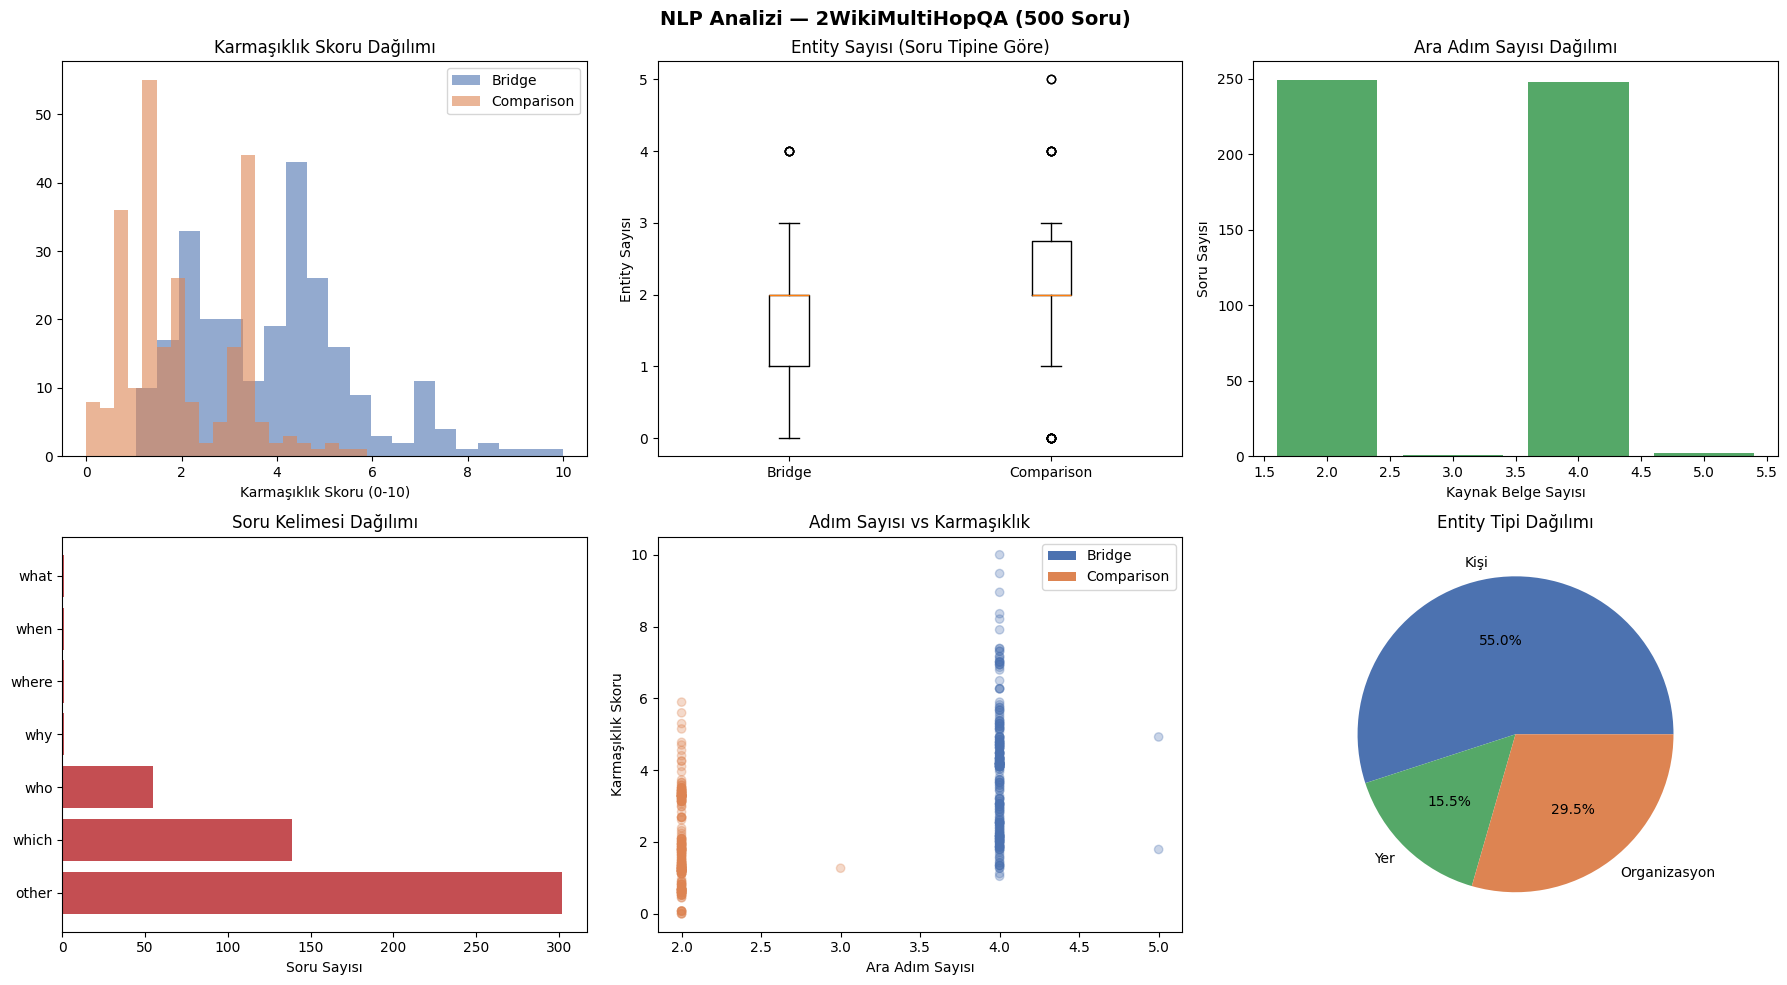

✅ Grafik kaydedildi!


In [12]:
#görselleştirme

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('NLP Analizi — 2WikiMultiHopQA (500 Soru)', fontsize=14, fontweight='bold')

bridge_df = df[df['tip'] == 'bridge_comparison']
comp_df = df[df['tip'] == 'comparison']

# 1. Karmaşıklık skoru dağılımı
axes[0,0].hist(bridge_df['karmashklik_skoru'], alpha=0.6, label='Bridge', color='#4C72B0', bins=20)
axes[0,0].hist(comp_df['karmashklik_skoru'], alpha=0.6, label='Comparison', color='#DD8452', bins=20)
axes[0,0].set_title('Karmaşıklık Skoru Dağılımı')
axes[0,0].set_xlabel('Karmaşıklık Skoru (0-10)')
axes[0,0].legend()

# 2. Entity sayısı boxplot
axes[0,1].boxplot(
    [bridge_df['entity_sayisi'], comp_df['entity_sayisi']],
    labels=['Bridge', 'Comparison']
)
axes[0,1].set_title('Entity Sayısı (Soru Tipine Göre)')
axes[0,1].set_ylabel('Entity Sayısı')

# 3. Ara adım sayısı dağılımı
adim_sayilari = df['ara_adim_sayisi'].value_counts().sort_index()
axes[0,2].bar(adim_sayilari.index, adim_sayilari.values, color='#55A868')
axes[0,2].set_title('Ara Adım Sayısı Dağılımı')
axes[0,2].set_xlabel('Kaynak Belge Sayısı')
axes[0,2].set_ylabel('Soru Sayısı')

# 4. Soru kelimesi dağılımı
soru_kel = df['soru_kelimesi'].value_counts().head(8)
axes[1,0].barh(soru_kel.index, soru_kel.values, color='#C44E52')
axes[1,0].set_title('Soru Kelimesi Dağılımı')
axes[1,0].set_xlabel('Soru Sayısı')

# 5. Karmaşıklık skoru vs Ara adım sayısı — NaN fix
# Rengi tip string yerine sayıya çevir
renk_map = {'bridge': '#4C72B0', 'bridge_comparison': '#4C72B0', 'comparison': '#DD8452'}
renkler = df['tip'].map(renk_map).fillna('#999999')  # NaN varsa gri yap

axes[1,1].scatter(
    df['ara_adim_sayisi'],
    df['karmashklik_skoru'],
    alpha=0.3,
    c=renkler.tolist()  # Series değil liste olarak ver
)
axes[1,1].set_title('Adım Sayısı vs Karmaşıklık')
axes[1,1].set_xlabel('Ara Adım Sayısı')
axes[1,1].set_ylabel('Karmaşıklık Skoru')

# Manuel legend ekle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Bridge'),
    Patch(facecolor='#DD8452', label='Comparison')
]
axes[1,1].legend(handles=legend_elements)

# 6. Entity tipi dağılımı
entity_tipleri = {
    'Kişi': df['kisi_sayisi'].sum(),
    'Yer': df['yer_sayisi'].sum(),
    'Organizasyon': df['org_sayisi'].sum(),
}
axes[1,2].pie(
    entity_tipleri.values(),
    labels=entity_tipleri.keys(),
    autopct='%1.1f%%',
    colors=['#4C72B0', '#55A868', '#DD8452']
)
axes[1,2].set_title('Entity Tipi Dağılımı')

plt.tight_layout()
plt.savefig('nlp_analiz_sonuclari.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik kaydedildi!')

## HÜCRE 12 — Sonuçları Kaydet
Tüm NLP özelliklerini içeren DataFrame'i kaydet. RAG/GraphRAG aşamasında buradan devam edeceğiz.

In [ ]:
# Triples sütununu JSON string'e çevir (CSV'ye kaydetmek için)
df_kayit = df.copy()
df_kayit['ner_entities'] = df_kayit['ner_entities'].apply(json.dumps)
df_kayit['supporting_facts'] = df_kayit['supporting_facts'].apply(json.dumps)

# Context çok büyük, kaydetmeyelim (zaten veri setinden tekrar çekilebilir)
df_kayit = df_kayit.drop(columns=['context', 'triples'], errors='ignore')

# Kaydet
df_kayit.to_csv('nlp_ozellikleri.csv', index=False, encoding='utf-8-sig')

print('✅ Kaydedildi: nlp_ozellikleri.csv')
print(f'\nDataset boyutu: {df_kayit.shape}')
print(f'\nSütunlar:')
for col in df_kayit.columns:
    print(f'  - {col}: {df_kayit[col].dtype}')

print(f'\n--- Özet İstatistikler ---')
print(df_kayit[[
    'entity_sayisi', 'karmashklik_skoru',
    'ara_adim_sayisi', 'fiil_sayisi', 'clause_sayisi'
]].describe().round(2))

print('\n✅ NLP Pipeline tamamlandı!')
print('Sıradaki adım: RAG ve GraphRAG sistemlerini kur.')

## ÖZET — Ne Yaptık?

| Adım | Yöntem | Ne Ölçüdük? |
|------|--------|-------------|
| Veri yükleme | HuggingFace datasets | 500 soru (250 bridge + 250 comparison) |
| NER | spaCy en_core_web_sm | Kişi, yer, org, tarih entity sayıları |
| Dependency Parsing | spaCy | Fiil, clause, bağlaç sayıları |
| Karmaşıklık skoru | Ağırlıklı formül | 0-10 arası normalize skor |
| Ara adım sayısı | Supporting facts | Kaç belgeden bilgi gerekiyor? |
| Triple Extraction | OpenIE | Özne-ilişki-nesne üçlüleri |



# RAG SİSTEMİ

In [ ]:
# RAG için gerekli kütüphaneler
!pip install -q langchain langchain-community chromadb sentence-transformers groq langchain-groq openai

print('✅ RAG kütüphaneleri yüklendi!')

In [ ]:
import os
from langchain_groq import ChatGroq

# Groq API anahtarını gir (ücretsiz: console.groq.com)
GROQ_API_KEY = "YOUR_GROQ_API_KEY_HERE"  # <-- Buraya kendi anahtarınızı girin
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

# LLM modelini başlat
llm = ChatGroq(
    model="llama-3.1-8b-instant",  # Ücretsiz ve hızlı
    temperature=0,                  # 0 = deterministik cevap
    api_key=GROQ_API_KEY
)

# Test et
test = llm.invoke("Merhaba, çalışıyor musun?")
print(f'✅ Model hazır: {test.content[:100]}')

✅ Model hazır: Merhaba! Evet, çalışıyorum. Size yardımcı olmayı ve sorularınıza cevap vermeyi istiyorsam, lütfen so


In [ ]:

from groq import Groq
import time
import numpy as np

client = Groq(api_key=GROQ_API_KEY)

def embed_metinler(metinler):
    """FAISS için embedding üret"""
    return embeddings.embed_documents(metinler)

def embed_soru(soru):
    """Soru için embedding üret"""
    return embeddings.embed_query(soru)

def kosinüs_benzerlik(vec1, vec2):
    """İki vektör arasındaki benzerliği hesapla"""
    v1, v2 = np.array(vec1), np.array(vec2)
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

def en_alakali_belgeleri_bul(soru, docs, k=3):
    """Soruya en benzer k belgeyi getir"""
    soru_emb = embed_soru(soru)
    doc_metinler = [d.page_content for d in docs]
    doc_embs = embed_metinler(doc_metinler)

    benzerlikler = [kosinüs_benzerlik(soru_emb, d_emb) for d_emb in doc_embs]
    en_iyi = sorted(enumerate(benzerlikler), key=lambda x: x[1], reverse=True)[:k]

    return [docs[i].page_content for i, _ in en_iyi]

def rag_cevapla(soru, context, soru_id, k=3):
    """Sade RAG: embed → retrieve → generate"""
    docs = context_to_documents(context, soru_id)
    if not docs:
        return {"cevap": "Belge bulunamadı", "sure": 0}

    try:
        # En alakalı belgeleri getir
        alakali_belgeler = en_alakali_belgeleri_bul(soru, docs, k=k)
        bagLam = "\n\n".join(alakali_belgeler)

        # LLM'e sor
        baslangic = time.time()
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            temperature=0,
            max_tokens=100,
            messages=[
                {
                    "role": "system",
                    "content": "Answer questions using only the provided context. Give only the answer, no explanation. If you cannot find the answer, say 'I don't know'."
                },
                {
                    "role": "user",
                    "content": f"Context:\n{bagLam}\n\nQuestion: {soru}\n\nAnswer:"
                }
            ]
        )
        sure = time.time() - baslangic
        cevap = response.choices[0].message.content.strip()

        return {"cevap": cevap, "sure": round(sure, 2)}

    except Exception as e:
        return {"cevap": f"HATA: {str(e)}", "sure": 0}

# Test
print('RAG test ediliyor...')
ornek = df.iloc[0]
sonuc = rag_cevapla(ornek['soru'], ornek['context'], ornek['id'])
print(f'Soru: {ornek["soru"]}')
print(f'Doğru cevap: {ornek["cevap"]}')
print(f'RAG cevabı: {sonuc["cevap"]}')
print(f'Süre: {sonuc["sure"]} sn')

RAG test ediliyor...
Soru: Does Shaun Berne have the same nationality as Michael Riley (Curler)?
Doğru cevap: no
RAG cevabı: I don't know
Süre: 0.15 sn


In [19]:
#Tüm Sorulara RAG Uygula
import json

print('RAG pipeline başlatılıyor...')
print(f'Toplam soru: {len(df)}')
print('Tahmini süre: ~15-20 dakika\n')

rag_sonuclari = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    sonuc = rag_cevapla(row['soru'], row['context'], row['id'])

    rag_sonuclari.append({
        'id': row['id'],
        'soru': row['soru'],
        'dogru_cevap': row['cevap'],
        'rag_cevap': sonuc['cevap'],
        'tip': row['tip'],
        'ara_adim_sayisi': row['ara_adim_sayisi'],
        'karmashklik_skoru': row['karmashklik_skoru'],
        'sure': sonuc['sure'],
    })

    # Her 50 soruda bir kaydet
    if (i + 1) % 50 == 0:
        pd.DataFrame(rag_sonuclari).to_csv(
            f'rag_sonuclari_ara_{i+1}.csv',
            index=False,
            encoding='utf-8-sig'
        )
        print(f'{i+1} soru tamamlandı...')

    # Rate limit için bekle
    time.sleep(0.3)

# Final kayıt
rag_df = pd.DataFrame(rag_sonuclari)
rag_df.to_csv('rag_sonuclari.csv', index=False, encoding='utf-8-sig')
print(f'\n✅ RAG tamamlandı! {len(rag_df)} soru işlendi.')
print(rag_df.head())

RAG pipeline başlatılıyor...
Toplam soru: 500
Tahmini süre: ~15-20 dakika



 10%|▉         | 49/500 [01:58<21:19,  2.84s/it]

50 soru tamamlandı...


 20%|█▉        | 99/500 [04:48<30:49,  4.61s/it]

100 soru tamamlandı...


...

450 soru tamamlandı...


100%|█████████▉| 499/500 [27:56<00:05,  5.36s/it]

500 soru tamamlandı...


100%|██████████| 500/500 [28:00<00:00,  3.36s/it]


✅ RAG tamamlandı! 500 soru işlendi.
                                 id  \
0  dc7fe05208f511ebbdaaac1f6bf848b6   
1  6ae3a80c08d011ebbd95ac1f6bf848b6   
2  08e1eac4086711ebbd5eac1f6bf848b6   
3  e5efda68094111ebbdaeac1f6bf848b6   
4  0f8bbfba086e11ebbd62ac1f6bf848b6   

                                                soru           dogru_cevap  \
0  Does Shaun Berne have the same nationality as ...                    no   
1  Are both Gabas (River) and San Pedro River (Ch...                    no   
2  Are Airbridge (band) and Dropdead from the sam...                    no   
3  Which film was released earlier, El Sonriure A...    El Sonriure Amagat   
4  Which film whose director was born first, How ...  To The Public Danger   

        rag_cevap                tip  ara_adim_sayisi  karmashklik_skoru  sure  
0    I don't know         comparison                2           0.970149  0.27  
1    I don't know         comparison                2           1.940299  0.13  
2              N

In [22]:

# Cevap Değerlendirme (Halüsinasyon Tespiti)
from difflib import SequenceMatcher

def cevap_degerlendir_llm(dogru_cevap, model_cevap):
    """
    LLM-as-a-Judge: Groq API kullanarak modelin cevabının anlamsal olarak
    doğru cevabı içerip içermediğini kontrol eder.
    """
    dogru = str(dogru_cevap).lower().strip()
    model = str(model_cevap).lower().strip()

    # "Bilmiyorum" tespiti (Burası aynı kalabilir, hız kazandırır)
    if 'bilmiyorum' in model or "i don't know" in model or 'cannot' in model:
        return {'dogru_mu': False, 'hata_tipi': 'cevapsiz'}

    # Tam eşleşme varsa LLM'e gitmeye gerek yok (Maliyet/Hız optimizasyonu)
    if dogru == model:
        return {'dogru_mu': True, 'hata_tipi': None}

    # Anlamsal kontrol için LLM'e sor
    prompt = f"""You are an expert evaluator.
    True Answer: {dogru_cevap}
    Model's Answer: {model_cevap}

    Does the model's answer contain or mean exactly the same thing as the true answer?
    Respond ONLY with 'YES' or 'NO'."""

    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            temperature=0,
            max_tokens=10,
            messages=[{"role": "user", "content": prompt}]
        )
        degerlendirme = response.choices[0].message.content.strip().upper()

        dogru_mu = 'YES' in degerlendirme
        return {
            'dogru_mu': dogru_mu,
            'hata_tipi': None if dogru_mu else 'yanlis_cevap'
        }
    except Exception as e:
        return {'dogru_mu': False, 'hata_tipi': 'degerlendirme_hatasi'}

# Tüm RAG sonuçlarına uygula
print('Cevaplar değerlendiriliyor...')
degerlendirmeler = [
    cevap_degerlendir_llm(row['dogru_cevap'], row['rag_cevap'])
    for _, row in rag_df.iterrows()
]

rag_df['dogru_mu'] = [d['dogru_mu'] for d in degerlendirmeler]
rag_df['hata_tipi'] = [d['hata_tipi'] for d in degerlendirmeler]

# Özet
print(f'\n=== RAG Performans Özeti ===')
print(f"Genel doğruluk: {rag_df['dogru_mu'].mean()*100:.1f}%")
print(f"Bridge doğruluk: {rag_df[rag_df['tip'].isin(['bridge','bridge_comparison'])]['dogru_mu'].mean()*100:.1f}%")
print(f"Comparison doğruluk: {rag_df[rag_df['tip']=='comparison']['dogru_mu'].mean()*100:.1f}%")

print(f'\nAdım sayısına göre doğruluk:')
print(rag_df.groupby('ara_adim_sayisi')['dogru_mu'].mean().apply(lambda x: f'{x*100:.1f}%'))

# Kaydet
rag_df.to_csv('rag_degerlendirilmis.csv', index=False, encoding='utf-8-sig')
print('\n✅ Kaydedildi: rag_degerlendirilmis.csv')

Cevaplar değerlendiriliyor...

=== RAG Performans Özeti ===
Genel doğruluk: 32.6%
Bridge doğruluk: 19.2%
Comparison doğruluk: 46.0%

Adım sayısına göre doğruluk:
ara_adim_sayisi
2     46.2%
3      0.0%
4     18.5%
5    100.0%
Name: dogru_mu, dtype: object

✅ Kaydedildi: rag_degerlendirilmis.csv


In [23]:
# Cevap dağılımını analiz et
print("=== Cevap Dağılımı ===")
bilmiyorum = rag_df['rag_cevap'].str.lower().str.contains("don't know|bilmiyorum|cannot", na=False)
print(f"'I don't know' diyen: {bilmiyorum.sum()} ({bilmiyorum.mean()*100:.1f}%)")
print(f"Cevap veren: {(~bilmiyorum).sum()} ({(~bilmiyorum).mean()*100:.1f}%)")

print("\n=== Cevap Veren Sorularda Doğruluk ===")
cevap_veren = rag_df[~bilmiyorum]
print(f"Doğruluk: {cevap_veren['dogru_mu'].mean()*100:.1f}%")

print("\n=== Tipe Göre 'I don't know' Oranı ===")
print(rag_df.groupby('tip').apply(
    lambda x: x['rag_cevap'].str.lower().str.contains("don't know|bilmiyorum|cannot", na=False).mean() * 100
).round(1).astype(str) + '%')

print("\n=== Adım Sayısına Göre 'I don't know' Oranı ===")
print(rag_df.groupby('ara_adim_sayisi').apply(
    lambda x: x['rag_cevap'].str.lower().str.contains("don't know|bilmiyorum|cannot", na=False).mean() * 100
).round(1).astype(str) + '%')

# Örnek yanlış cevaplar
print("\n=== Örnek Yanlış Cevaplar (ilk 5) ===")
yanlis = rag_df[rag_df['dogru_mu'] == False].head(5)
for _, row in yanlis.iterrows():
    print(f"Soru: {row['soru'][:60]}...")
    print(f"Doğru: {row['dogru_cevap']} | RAG: {row['rag_cevap']}")
    print()

=== Cevap Dağılımı ===
'I don't know' diyen: 286 (57.2%)
Cevap veren: 214 (42.8%)

=== Cevap Veren Sorularda Doğruluk ===
Doğruluk: 76.2%

=== Tipe Göre 'I don't know' Oranı ===
tip
bridge_comparison    70.4%
comparison           44.0%
dtype: object

=== Adım Sayısına Göre 'I don't know' Oranı ===
ara_adim_sayisi
2     43.8%
3    100.0%
4     71.0%
5      0.0%
dtype: object

=== Örnek Yanlış Cevaplar (ilk 5) ===
Soru: Does Shaun Berne have the same nationality as Michael Riley ...
Doğru: no | RAG: I don't know

Soru: Are both Gabas (River) and San Pedro River (Chihuahua) locat...
Doğru: no | RAG: I don't know

Soru: Which film was released earlier, El Sonriure Amagat or Maste...
Doğru: El Sonriure Amagat | RAG: Masters (Film)

Soru: Which film whose director was born first, How I Learned To L...
Doğru: To The Public Danger | RAG: I don't know

Soru: Which film was released first, Christopher Columbus – The En...
Doğru: Christopher Columbus – The Enigma | RAG: I don't know



# GraphRAG

NetworkX ile Bilgi Grafiği Kur

In [24]:
!pip install -q networkx
import networkx as nx

def bilgi_grafigi_olustur(context, supporting_facts):
    """
    Context'teki belgelerden triple çıkarıp bilgi grafiği oluşturur.
    Her makale = düğüm, her ilişki = kenar.
    """
    G = nx.DiGraph()

    for makale_adi, cumleler in zip(context['title'], context['sentences']):
        metin = ' '.join(cumleler)
        doc = nlp(metin)

        # Makale düğümünü ekle
        G.add_node(makale_adi, tip='makale', metin=metin[:300])

        # Triple çıkar ve grafiğe ekle
        for token in doc:
            if token.pos_ == 'VERB':
                ozne = None
                nesne = None

                for child in token.children:
                    if child.dep_ in ('nsubj', 'nsubjpass'):
                        ozne = ' '.join([t.text for t in child.subtree
                                        if not t.is_punct]).strip()
                    if child.dep_ in ('dobj', 'pobj', 'attr'):
                        nesne = ' '.join([t.text for t in child.subtree
                                         if not t.is_punct]).strip()

                if ozne and nesne and len(ozne) < 50 and len(nesne) < 50:
                    # Düğümleri ekle
                    if not G.has_node(ozne):
                        G.add_node(ozne, tip='entity')
                    if not G.has_node(nesne):
                        G.add_node(nesne, tip='entity')

                    # Kenarı ekle (ilişki = fiilin kök hali)
                    G.add_edge(
                        ozne, nesne,
                        iliski=token.lemma_,
                        kaynak_makale=makale_adi
                    )

    return G

# Test
ornek = df.iloc[4]  # bridge_comparison olan bir soru
G = bilgi_grafigi_olustur(ornek['context'], ornek['supporting_facts'])
print(f'Test sorusu: {ornek["soru"]}')
print(f'Düğüm sayısı: {G.number_of_nodes()}')
print(f'Kenar sayısı: {G.number_of_edges()}')
print(f'\nİlk 5 kenar (özne → iliski → nesne):')
for u, v, data in list(G.edges(data=True))[:5]:
    print(f'  {u} --[{data["iliski"]}]--> {v}')

Test sorusu: Which film whose director was born first, How I Learned To Love Women or To The Public Danger?
Düğüm sayısı: 18
Kenar sayısı: 5

İlk 5 kenar (özne → iliski → nesne):
  who --[spend]--> most of his life in New Zealand
  who --[play]--> 17 matches
  who --[defeat]--> the powers of darkness
  he --[use]--> the pseudonym Pilantra
  which --[launch]--> Hammer 's association


Sorudan Varlık Çıkar ve Grafikte Ara

In [25]:
def soru_varliklarini_bul(soru):
    """Sorudaki NER varlıklarını tespit et."""
    doc = nlp(soru)
    varliklar = [ent.text for ent in doc.ents]

    # NER bulamazsa önemli isimleri al (proper noun)
    if not varliklar:
        varliklar = [token.text for token in doc
                     if token.pos_ == 'PROPN' and len(token.text) > 2]

    return list(set(varliklar))

def grafik_uzerinde_ara(G, varliklar, derinlik=2):
    """
    Sorudaki varlıklara yakın düğümleri ve kenarları bul.
    derinlik: kaç adım uzağa gidilecek
    """
    ilgili_triples = []
    bulunan_dugumler = set()

    for varlik in varliklar:
        # Tam eşleşme ara
        eslesen_dugumler = [
            node for node in G.nodes()
            if varlik.lower() in node.lower() or node.lower() in varlik.lower()
        ]

        for dugum in eslesen_dugumler:
            bulunan_dugumler.add(dugum)

            # Bu düğümden çıkan kenarlar
            for u, v, data in G.edges(dugum, data=True):
                ilgili_triples.append(f"{u} --[{data['iliski']}]--> {v}")

            # Bu düğüme gelen kenarlar
            for u, v, data in G.in_edges(dugum, data=True):
                ilgili_triples.append(f"{u} --[{data['iliski']}]--> {v}")

            # derinlik 2 ise komşuların komşularına da bak
            if derinlik >= 2:
                for komsu in list(G.neighbors(dugum)):
                    for u, v, data in G.edges(komsu, data=True):
                        ilgili_triples.append(f"{u} --[{data['iliski']}]--> {v}")

    # Tekrarları temizle
    return list(set(ilgili_triples))

# Test
soru = ornek['soru']
varliklar = soru_varliklarini_bul(soru)
print(f'Soru: {soru}')
print(f'Bulunan varlıklar: {varliklar}')

ilgili = grafik_uzerinde_ara(G, varliklar)
print(f'\nİlgili triple sayısı: {len(ilgili)}')
for t in ilgili[:5]:
    print(f'  {t}')

Soru: Which film whose director was born first, How I Learned To Love Women or To The Public Danger?
Bulunan varlıklar: ['first', 'The Public Danger']

İlgili triple sayısı: 1
  he --[use]--> the pseudonym Pilantra


GraphRAG Fonksiyonu

In [26]:
def graphrag_cevapla(soru, context, supporting_facts, soru_id):
    """
    GraphRAG pipeline:
    1. Bilgi grafiği oluştur
    2. Sorudaki varlıkları bul
    3. Grafik üzerinde ilgili triple'ları topla
    4. LLM'e yapılandırılmış bağlam olarak ver
    """
    try:
        # 1. Bilgi grafiği oluştur
        G = bilgi_grafigi_olustur(context, supporting_facts)

        if G.number_of_edges() == 0:
            return {"cevap": "Graf oluşturulamadı", "sure": 0, "triple_sayisi": 0}

        # 2. Sorudaki varlıkları bul
        varliklar = soru_varliklarini_bul(soru)

        # 3. İlgili triple'ları topla
        ilgili_triples = grafik_uzerinde_ara(G, varliklar, derinlik=2)

        # Triple bulunamazsa tüm kenarları kullan (fallback)
        if not ilgili_triples:
          ilgili_triples = []


        # Makale metinlerini de ekle (hibrit yaklaşım)
        sf_basliklar = supporting_facts['title']
        makale_metinleri = []
        for baslik, cumleler in zip(context['title'], context['sentences']):
            if baslik in sf_basliklar:
                makale_metinleri.append(f"{baslik}: {' '.join(cumleler[:2])}")

        # 4. LLM'e gönder
        bagLam = "KNOWLEDGE GRAPH TRIPLES:\n" + "\n".join(ilgili_triples[:25])
        if makale_metinleri:
            bagLam += "\n\nSOURCE PASSAGES:\n" + "\n".join(makale_metinleri)

        baslangic = time.time()
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            temperature=0,
            max_tokens=100,
            messages=[
                {
                    "role": "system",
                    "content": """You are a precise question answering system.
Use the provided knowledge graph triples and source passages to answer.
The triples show relationships: entity --[relation]--> entity.
Follow the relationship chain to find the answer.
Give ONLY the answer, nothing else. If truly cannot answer, say 'I don't know'."""
                },
                {
                    "role": "user",
                    "content": f"{bagLam}\n\nQuestion: {soru}\n\nAnswer:"
                }
            ]
        )
        sure = time.time() - baslangic
        cevap = response.choices[0].message.content.strip()

        return {
            "cevap": cevap,
            "sure": round(sure, 2),
            "triple_sayisi": len(ilgili_triples),
            "varlik_sayisi": len(varliklar)
        }

    except Exception as e:
        return {"cevap": f"HATA: {str(e)}", "sure": 0, "triple_sayisi": 0}

# Test — RAG ile karşılaştır
print('GraphRAG test ediliyor...')
ornek = df.iloc[0]
sonuc = graphrag_cevapla(
    ornek['soru'],
    ornek['context'],
    ornek['supporting_facts'],
    ornek['id']
)
print(f'Soru: {ornek["soru"]}')
print(f'Doğru cevap: {ornek["cevap"]}')
print(f'RAG cevabı: {rag_df.iloc[0]["rag_cevap"]}')
print(f'GraphRAG cevabı: {sonuc["cevap"]}')
print(f'Kullanılan triple sayısı: {sonuc["triple_sayisi"]}')
print(f'Süre: {sonuc["sure"]} sn')

GraphRAG test ediliyor...
Soru: Does Shaun Berne have the same nationality as Michael Riley (Curler)?
Doğru cevap: no
RAG cevabı: I don't know
GraphRAG cevabı: I don't know
Kullanılan triple sayısı: 0
Süre: 0.13 sn


Tüm Sorulara GraphRAG Uygula

In [ ]:
print('GraphRAG pipeline başlatılıyor...')
print(f'Toplam soru: {len(df)}')
print('Tahmini süre: ~20-25 dakika\n')

graphrag_sonuclari = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    # supporting_facts string olarak kaydedildiyse parse et
    sf = row['supporting_facts']
    if isinstance(sf, str):
        import json
        sf = json.loads(sf)

    sonuc = graphrag_cevapla(
        row['soru'],
        row['context'],
        sf,
        row['id']
    )

    graphrag_sonuclari.append({
        'id': row['id'],
        'soru': row['soru'],
        'dogru_cevap': row['cevap'],
        'graphrag_cevap': sonuc['cevap'],
        'tip': row['tip'],
        'ara_adim_sayisi': row['ara_adim_sayisi'],
        'karmashklik_skoru': row['karmashklik_skoru'],
        'triple_sayisi': sonuc['triple_sayisi'],
        'sure': sonuc['sure'],
    })

    if (i + 1) % 50 == 0:
        pd.DataFrame(graphrag_sonuclari).to_csv(
            f'graphrag_sonuclari_ara_{i+1}.csv',
            index=False, encoding='utf-8-sig'
        )
        print(f'{i+1} soru tamamlandı...')

    time.sleep(0.3)

graphrag_df = pd.DataFrame(graphrag_sonuclari)
graphrag_df.to_csv('graphrag_sonuclari.csv', index=False, encoding='utf-8-sig')
print(f'\n✅ GraphRAG tamamlandı! {len(graphrag_df)} soru işlendi.')

GraphRAG pipeline başlatılıyor...
Toplam soru: 500
Tahmini süre: ~20-25 dakika



 10%|▉         | 49/500 [01:30<22:27,  2.99s/it]

50 soru tamamlandı...


 20%|█▉        | 99/500 [04:20<26:20,  3.94s/it]

100 soru tamamlandı...


...

450 soru tamamlandı...


100%|█████████▉| 499/500 [1:43:39<00:37, 37.44s/it]

500 soru tamamlandı...


100%|██████████| 500/500 [1:43:40<00:00, 12.44s/it]


✅ GraphRAG tamamlandı! 500 soru işlendi.


GraphRAG Değerlendirme ve RAG ile Karşılaştır

In [30]:
from tqdm import tqdm
import time

print('GraphRAG cevapları LLM ile değerlendiriliyor...')

# List comprehension yerine standart döngü ve progress bar kullanıyoruz
degerlendirmeler = []
for i, row in tqdm(graphrag_df.iterrows(), total=len(graphrag_df)):
    # LLM-as-a-judge fonksiyonunu çağır
    sonuc = cevap_degerlendir_llm(row['dogru_cevap'], row['graphrag_cevap'])
    degerlendirmeler.append(sonuc)

    # API limitine takılmamak için her soruda çeyrek saniye bekle
    time.sleep(0.3)

# Sonuçları DataFrame'e aktar
graphrag_df['dogru_mu'] = [d['dogru_mu'] for d in degerlendirmeler]
graphrag_df['benzerlik'] = [d.get('benzerlik', 0.0) for d in degerlendirmeler] # LLM fonksiyonunda benzerlik dönmüyorsa hata vermemesi için get() kullandık

# "I don't know" oranı hesaplaması
bilmiyorum_gr = graphrag_df['graphrag_cevap'].str.lower().str.contains(
    "don't know|bilmiyorum|cannot", na=False
)

print('=' * 50)
print('      RAG vs GraphRAG KARŞILAŞTIRMA')
print('=' * 50)

print(f'\n📊 Genel Doğruluk:')
print(f'   RAG:      {rag_df["dogru_mu"].mean()*100:.1f}%')
print(f'   GraphRAG: {graphrag_df["dogru_mu"].mean()*100:.1f}%')

print(f'\n🤷 "I don\'t know" Oranı:')
bilmiyorum_rag = rag_df['rag_cevap'].str.lower().str.contains(
    "don't know|bilmiyorum|cannot", na=False
)
print(f'   RAG:      {bilmiyorum_rag.mean()*100:.1f}%')
print(f'   GraphRAG: {bilmiyorum_gr.mean()*100:.1f}%')

print(f'\n📈 Adım Sayısına Göre Doğruluk:')
print(f'   {"Adım":<8} {"RAG":>10} {"GraphRAG":>12}')
for adim in sorted(df['ara_adim_sayisi'].unique()):
    rag_acc = rag_df[rag_df['ara_adim_sayisi']==adim]['dogru_mu'].mean()*100
    gr_acc = graphrag_df[graphrag_df['ara_adim_sayisi']==adim]['dogru_mu'].mean()*100
    print(f'   {adim:<8} {rag_acc:>9.1f}% {gr_acc:>11.1f}%')

print(f'\n📈 Soru Tipine Göre Doğruluk:')
print(f'   {"Tip":<20} {"RAG":>8} {"GraphRAG":>12}')
for tip in df['tip'].unique():
    rag_acc = rag_df[rag_df['tip']==tip]['dogru_mu'].mean()*100
    gr_acc = graphrag_df[graphrag_df['tip']==tip]['dogru_mu'].mean()*100
    print(f'   {tip:<20} {rag_acc:>7.1f}% {gr_acc:>11.1f}%')

# Drive'a kaydet
graphrag_df.to_csv('graphrag_degerlendirilmis.csv', index=False, encoding='utf-8-sig')
import shutil
shutil.copy('graphrag_degerlendirilmis.csv',
            '/content/drive/MyDrive/multihop_proje/graphrag_degerlendirilmis.csv')
print('\n✅ Kaydedildi!')

GraphRAG cevapları LLM ile değerlendiriliyor...


100%|██████████| 500/500 [2:04:51<00:00, 14.98s/it]

      RAG vs GraphRAG KARŞILAŞTIRMA

📊 Genel Doğruluk:
   RAG:      32.6%
   GraphRAG: 30.0%

🤷 "I don't know" Oranı:
   RAG:      57.2%
   GraphRAG: 19.6%

📈 Adım Sayısına Göre Doğruluk:
   Adım            RAG     GraphRAG
   2             46.2%        36.9%
   3              0.0%         0.0%
   4             18.5%        23.0%
   5            100.0%        50.0%

📈 Soru Tipine Göre Doğruluk:
   Tip                       RAG     GraphRAG
   comparison              46.0%        36.8%
   bridge_comparison       19.2%        23.2%


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/multihop_proje/graphrag_degerlendirilmis.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [31]:
# ── ORTAK METRİK HESAPLAMA HÜCRESİ ──────────────────────────
# Tüm görselleştirmeler buradan dinamik olarak beslenir

def bilmiyorum_orani(df, cevap_col, tip=None):
    """Verilen DataFrame'de 'I don't know' oranını hesaplar."""
    if tip:
        df = df[df['tip'] == tip]
    oran = df[cevap_col].str.lower().str.contains(
        "don't know|bilmiyorum|cannot", na=False
    ).mean() * 100
    return round(oran, 1)

def dogruluk_hesapla(df, tip=None):
    """Verilen DataFrame'de doğruluk oranını hesaplar."""
    if tip:
        df = df[df['tip'] == tip]
    return round(df['dogru_mu'].mean() * 100, 1)

def adim_bazli_dogruluk(df, adim_sayisi):
    """Belirli adım sayısına göre doğruluğu hesaplar."""
    return round(df[df['ara_adim_sayisi'] == adim_sayisi]['dogru_mu'].mean() * 100, 1)

# ── Genel doğruluklar
rag_genel      = dogruluk_hesapla(rag_df)
graphrag_genel = dogruluk_hesapla(graphrag_df)

# ── "I don't know" oranları (genel)
rag_bm_genel      = bilmiyorum_orani(rag_df, 'rag_cevap')
graphrag_bm_genel = bilmiyorum_orani(graphrag_df, 'graphrag_cevap')
bm_fark = round(rag_bm_genel - graphrag_bm_genel, 1)

# ── Adım sayısına göre doğruluk
adim_sayilari = sorted(rag_df['ara_adim_sayisi'].unique())

rag_adim_acc      = [adim_bazli_dogruluk(rag_df, a) for a in adim_sayilari]
graphrag_adim_acc = [adim_bazli_dogruluk(graphrag_df, a) for a in adim_sayilari]

# ── Tipe göre "I don't know" oranları
rag_bm_comp   = bilmiyorum_orani(rag_df, 'rag_cevap', 'comparison')
rag_bm_bridge = bilmiyorum_orani(rag_df, 'rag_cevap', 'bridge_comparison')

graphrag_bm_comp   = bilmiyorum_orani(graphrag_df, 'graphrag_cevap', 'comparison')
graphrag_bm_bridge = bilmiyorum_orani(graphrag_df, 'graphrag_cevap', 'bridge_comparison')

# ── Tipe göre doğruluk
rag_comp      = dogruluk_hesapla(rag_df, 'comparison')
rag_bridge    = dogruluk_hesapla(rag_df, 'bridge_comparison')
graphrag_comp = dogruluk_hesapla(graphrag_df, 'comparison')
graphrag_bridge = dogruluk_hesapla(graphrag_df, 'bridge_comparison')

# ── Kontrol çıktısı
print("=== Hesaplanan Metrikler ===")
print(f"RAG Genel Doğruluk       : %{rag_genel}")
print(f"GraphRAG Genel Doğruluk  : %{graphrag_genel}")
print(f"RAG 'Bilmiyorum' Oranı   : %{rag_bm_genel}")
print(f"GraphRAG 'Bilmiyorum'    : %{graphrag_bm_genel}")
print(f"Fark                     : %{bm_fark} azalma")
print(f"\nAdım Sayıları            : {adim_sayilari}")
print(f"RAG Adım Bazlı Doğruluk  : {rag_adim_acc}")
print(f"GraphRAG Adım Bazlı      : {graphrag_adim_acc}")
print(f"\nRAG Comparison           : %{rag_comp}")
print(f"RAG Bridge               : %{rag_bridge}")
print(f"GraphRAG Comparison      : %{graphrag_comp}")
print(f"GraphRAG Bridge          : %{graphrag_bridge}")

# ── Görselleştirme için yeterli örneği olan adımları filtrele
MIN_ORNEK = 10
adim_sayilari_gorsellestirme = [
    a for a in adim_sayilari
    if len(rag_df[rag_df['ara_adim_sayisi'] == a]) >= MIN_ORNEK
]

rag_adim_acc_gorsellestirme      = [adim_bazli_dogruluk(rag_df, a)
                                     for a in adim_sayilari_gorsellestirme]
graphrag_adim_acc_gorsellestirme = [adim_bazli_dogruluk(graphrag_df, a)
                                     for a in adim_sayilari_gorsellestirme]

tip_etiketleri = {2: 'Comparison', 4: 'Bridge'}
adim_etiketleri = [
    f"{a} Adım\n({tip_etiketleri.get(int(a), 'Diğer')})"
    for a in adim_sayilari_gorsellestirme  # ← sadece filtrelenmiş adımlar
]

print("\nYeterli örnek olan adım sayıları:")
for a in adim_sayilari:
    n = len(rag_df[rag_df['ara_adim_sayisi'] == a])
    durum = "✅ dahil" if n >= MIN_ORNEK else "❌ hariç (az örnek)"
    print(f"  {a} adım: {n} soru → {durum}")

=== Hesaplanan Metrikler ===
RAG Genel Doğruluk       : %32.6
GraphRAG Genel Doğruluk  : %30.0
RAG 'Bilmiyorum' Oranı   : %57.2
GraphRAG 'Bilmiyorum'    : %19.6
Fark                     : %37.6 azalma

Adım Sayıları            : [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
RAG Adım Bazlı Doğruluk  : [np.float64(46.2), np.float64(0.0), np.float64(18.5), np.float64(100.0)]
GraphRAG Adım Bazlı      : [np.float64(36.9), np.float64(0.0), np.float64(23.0), np.float64(50.0)]

RAG Comparison           : %46.0
RAG Bridge               : %19.2
GraphRAG Comparison      : %36.8
GraphRAG Bridge          : %23.2

Yeterli örnek olan adım sayıları:
  2 adım: 249 soru → ✅ dahil
  3 adım: 1 soru → ❌ hariç (az örnek)
  4 adım: 248 soru → ✅ dahil
  5 adım: 2 soru → ❌ hariç (az örnek)


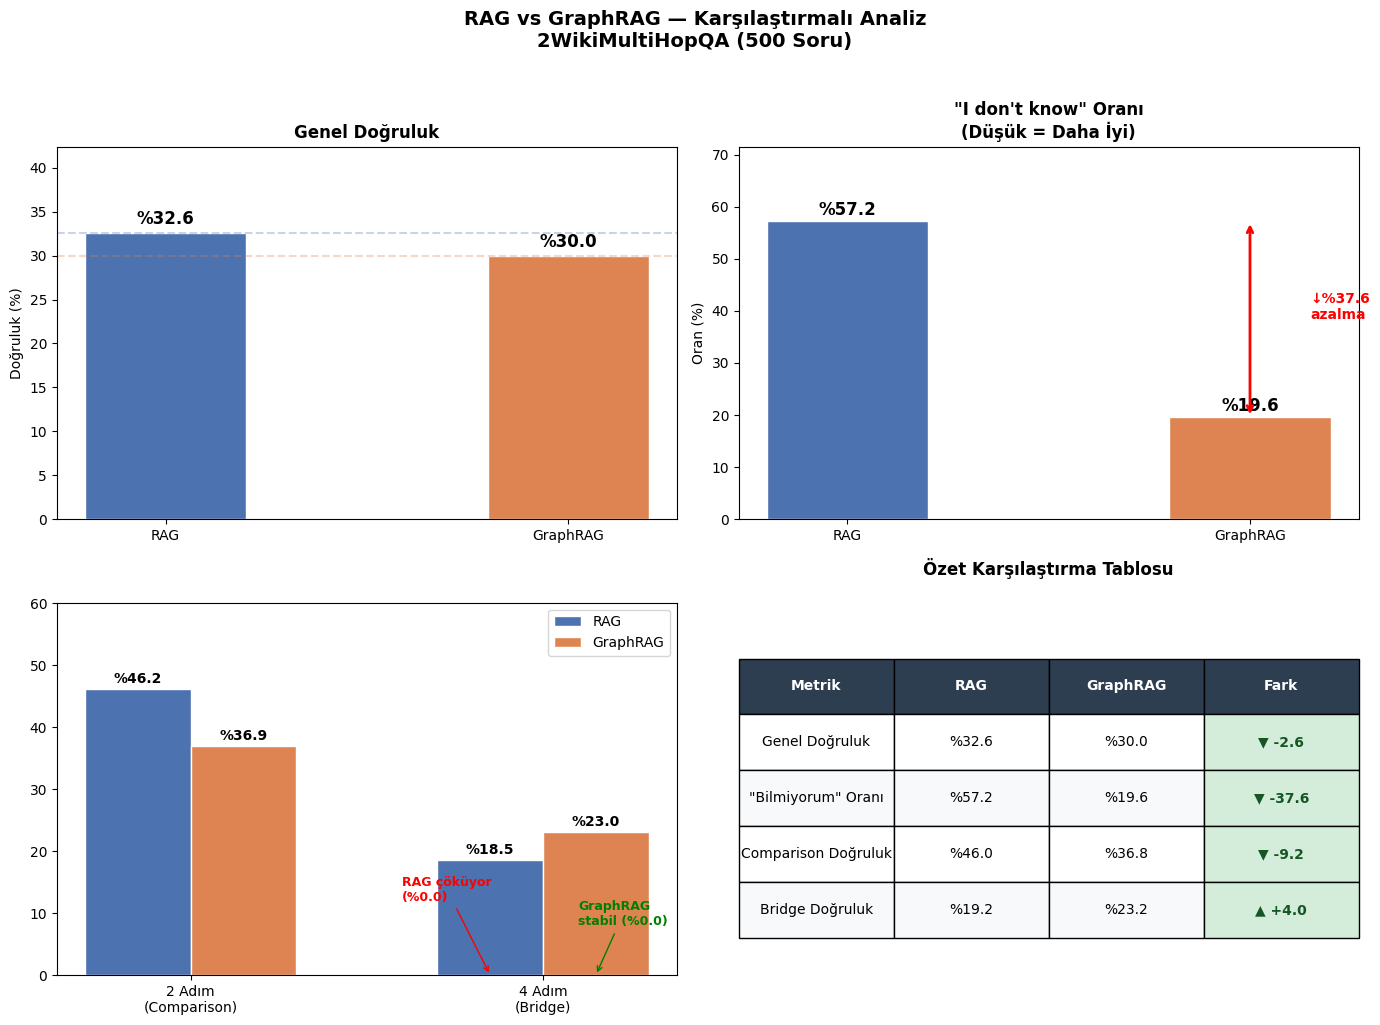

✅ Grafik kaydedildi: rag_vs_graphrag_sonuclar.png


In [32]:
# ── RAG vs GraphRAG Görselleştirme ───────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RAG vs GraphRAG — Karşılaştırmalı Analiz\n2WikiMultiHopQA (500 Soru)',
             fontsize=14, fontweight='bold', y=1.02)

renkler = {'RAG': '#4C72B0', 'GraphRAG': '#DD8452'}

# ── 1. Genel Doğruluk ──────────────────────────────────────
ax1 = axes[0, 0]
sistemler = ['RAG', 'GraphRAG']
dogruluklar = [rag_genel, graphrag_genel]  # Dinamik

bars = ax1.bar(sistemler, dogruluklar,
               color=[renkler['RAG'], renkler['GraphRAG']],
               width=0.4, edgecolor='white')

for bar, val in zip(bars, dogruluklar):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'%{val}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax1.set_title('Genel Doğruluk', fontweight='bold')
ax1.set_ylabel('Doğruluk (%)')
ax1.set_ylim(0, max(dogruluklar) * 1.3)  # Dinamik üst sınır
ax1.axhline(y=rag_genel, color=renkler['RAG'], linestyle='--', alpha=0.3)
ax1.axhline(y=graphrag_genel, color=renkler['GraphRAG'], linestyle='--', alpha=0.3)

# ── 2. "I don't know" Oranı ────────────────────────────────
ax2 = axes[0, 1]
bilmiyorum_vals = [rag_bm_genel, graphrag_bm_genel]  # Dinamik

bars2 = ax2.bar(sistemler, bilmiyorum_vals,
                color=[renkler['RAG'], renkler['GraphRAG']],
                width=0.4, edgecolor='white')

for bar, val in zip(bars2, bilmiyorum_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'%{val}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax2.set_title('"I don\'t know" Oranı\n(Düşük = Daha İyi)', fontweight='bold')
ax2.set_ylabel('Oran (%)')
ax2.set_ylim(0, max(bilmiyorum_vals) * 1.25)

# Fark oku — dinamik
ax2.annotate('', xy=(1, graphrag_bm_genel), xytext=(1, rag_bm_genel),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax2.text(1.15, (rag_bm_genel + graphrag_bm_genel) / 2,
         f'↓%{bm_fark}\nazalma', color='red', fontsize=10, fontweight='bold')

# ── 3. Adım Sayısına Göre Doğruluk ─────────────────────────
ax3 = axes[1, 0]
x = np.arange(len(adim_sayilari_gorsellestirme))
genislik = 0.3

# X ekseni etiketleri dinamik
tip_etiketleri = {2: 'Comparison', 4: 'Bridge'}
adim_etiketleri = [
    f"{a} Adım\n({tip_etiketleri.get(int(a), 'Diğer')})"
    for a in adim_sayilari_gorsellestirme  # ← sadece filtrelenmiş adımlar
]

b1 = ax3.bar(x - genislik/2, rag_adim_acc_gorsellestirme, genislik,
             label='RAG', color=renkler['RAG'], edgecolor='white')
b2 = ax3.bar(x + genislik/2, graphrag_adim_acc_gorsellestirme, genislik,
             label='GraphRAG', color=renkler['GraphRAG'], edgecolor='white')


for bar, val in zip(b1, rag_adim_acc_gorsellestirme):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'%{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(b2, graphrag_adim_acc_gorsellestirme):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'%{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_xticks(x)
ax3.set_xticklabels(adim_etiketleri)
ax3.set_ylim(0, max(rag_adim_acc_gorsellestirme +
                    graphrag_adim_acc_gorsellestirme) * 1.3)


ax3.legend()

# En büyük farkı otomatik bul ve vurgula
farklar = [g - r for r, g in zip(rag_adim_acc_gorsellestirme,
                                   graphrag_adim_acc_gorsellestirme)]
en_buyuk_fark_idx = farklar.index(max(farklar))
en_dusuk_rag_idx  = rag_adim_acc_gorsellestirme.index(
                        min(rag_adim_acc_gorsellestirme))

ax3.annotate(f'RAG çöküyor\n(%{rag_adim_acc[en_dusuk_rag_idx]})',
             xy=(en_dusuk_rag_idx - genislik/2,
                 rag_adim_acc[en_dusuk_rag_idx]),
             xytext=(en_dusuk_rag_idx - 0.4,
                     rag_adim_acc[en_dusuk_rag_idx] + 12),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontsize=9, fontweight='bold')

ax3.annotate(f'GraphRAG\nstabil (%{graphrag_adim_acc[en_buyuk_fark_idx]})',
             xy=(en_buyuk_fark_idx + genislik/2,
                 graphrag_adim_acc[en_buyuk_fark_idx]),
             xytext=(en_buyuk_fark_idx + 0.1,
                     graphrag_adim_acc[en_buyuk_fark_idx] + 8),
             arrowprops=dict(arrowstyle='->', color='green'),
             color='green', fontsize=9, fontweight='bold')

# ── 4. Özet Tablo ───────────────────────────────────────────
ax4 = axes[1, 1]
ax4.axis('off')

fark_genel  = round(graphrag_genel - rag_genel, 1)
fark_bm     = round(rag_bm_genel - graphrag_bm_genel, 1)
fark_comp   = round(graphrag_comp - rag_comp, 1)
fark_bridge = round(graphrag_bridge - rag_bridge, 1)

def fark_str(f):
    return f'▲ +{f}' if f > 0 else f'▼ {f}'

tablo_data = [
    ['Metrik', 'RAG', 'GraphRAG', 'Fark'],
    ['Genel Doğruluk',    f'%{rag_genel}',    f'%{graphrag_genel}', fark_str(fark_genel)],
    ['"Bilmiyorum" Oranı',f'%{rag_bm_genel}', f'%{graphrag_bm_genel}', f'▼ -{fark_bm}'],
    ['Comparison Doğruluk',f'%{rag_comp}',    f'%{graphrag_comp}',  fark_str(fark_comp)],
    ['Bridge Doğruluk',   f'%{rag_bridge}',   f'%{graphrag_bridge}',fark_str(fark_bridge)],
]

tablo = ax4.table(
    cellText=tablo_data[1:],
    colLabels=tablo_data[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0.1, 1, 0.75]
)
tablo.auto_set_font_size(False)
tablo.set_fontsize(10)

for (row, col), cell in tablo.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 3:
        text = cell.get_text().get_text()
        if '▲' in text:
            cell.set_facecolor('#d4edda')
            cell.set_text_props(color='#155724', fontweight='bold')
        elif '▼' in text and '-' in text and fark_bm > 0:
            cell.set_facecolor('#d4edda')  # Bilmiyorum azalması iyi
            cell.set_text_props(color='#155724', fontweight='bold')
        else:
            cell.set_facecolor('#fff3cd')
            cell.set_text_props(color='#856404')
    elif row % 2 == 0:
        cell.set_facecolor('#f8f9fa')

ax4.set_title('Özet Karşılaştırma Tablosu', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('rag_vs_graphrag_sonuclar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik kaydedildi: rag_vs_graphrag_sonuclar.png')

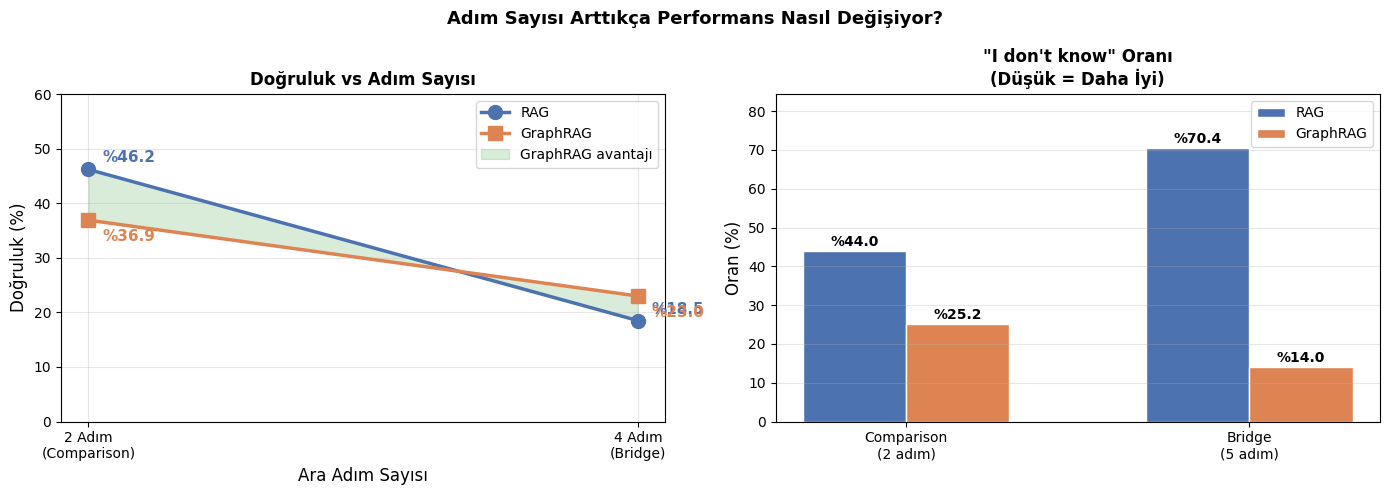

✅ Grafik kaydedildi: adim_sayisi_vs_performans.png


In [33]:
# ── Adım Sayısı vs Halüsinasyon ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Adım Sayısı Arttıkça Performans Nasıl Değişiyor?',
             fontsize=13, fontweight='bold')

# ── Sol: Doğruluk çizgi grafiği ────────────────────────────
ax1 = axes[0]

ax1.plot(adim_sayilari_gorsellestirme, rag_adim_acc_gorsellestirme, 'o-',
         color=renkler['RAG'], linewidth=2.5, markersize=10,
         label='RAG', zorder=3)
ax1.plot(adim_sayilari_gorsellestirme, graphrag_adim_acc_gorsellestirme, 's-',
         color=renkler['GraphRAG'], linewidth=2.5, markersize=10,
         label='GraphRAG', zorder=3)

for a, r, g in zip(adim_sayilari_gorsellestirme,
                   rag_adim_acc_gorsellestirme,
                   graphrag_adim_acc_gorsellestirme):
    ax1.annotate(f'%{r}', (a, r), textcoords='offset points',
                 xytext=(10, 5), fontsize=11,
                 color=renkler['RAG'], fontweight='bold')
    ax1.annotate(f'%{g}', (a, g), textcoords='offset points',
                 xytext=(10, -15), fontsize=11,
                 color=renkler['GraphRAG'], fontweight='bold')


ax1.fill_between(adim_sayilari_gorsellestirme,
                 rag_adim_acc_gorsellestirme,
                 graphrag_adim_acc_gorsellestirme,
                 alpha=0.15, color='green', label='GraphRAG avantajı')
ax1.set_xlabel('Ara Adım Sayısı', fontsize=12)
ax1.set_ylabel('Doğruluk (%)', fontsize=12)
ax1.set_title('Doğruluk vs Adım Sayısı', fontweight='bold')
ax1.set_xticks(adim_sayilari_gorsellestirme)
ax1.set_xticklabels(adim_etiketleri)
ax1.set_ylim(0, max(rag_adim_acc_gorsellestirme +
                    graphrag_adim_acc_gorsellestirme) * 1.3)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Sağ: "Bilmiyorum" oranı tipe göre ──────────────────────
ax2 = axes[1]

rag_bm_vals      = [rag_bm_comp, rag_bm_bridge]        # Dinamik
graphrag_bm_vals = [graphrag_bm_comp, graphrag_bm_bridge]  # Dinamik
kategoriler = [f'Comparison\n({adim_sayilari[0]} adım)',
               f'Bridge\n({adim_sayilari[-1]} adım)']

x = np.arange(len(kategoriler))
genislik = 0.3

b1 = ax2.bar(x - genislik/2, rag_bm_vals, genislik,
             label='RAG', color=renkler['RAG'], edgecolor='white')
b2 = ax2.bar(x + genislik/2, graphrag_bm_vals, genislik,
             label='GraphRAG', color=renkler['GraphRAG'], edgecolor='white')

for bar, val in zip(b1, rag_bm_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'%{val}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
for bar, val in zip(b2, graphrag_bm_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'%{val}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax2.set_title('"I don\'t know" Oranı\n(Düşük = Daha İyi)', fontweight='bold')
ax2.set_ylabel('Oran (%)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(kategoriler)
ax2.set_ylim(0, max(rag_bm_vals + graphrag_bm_vals) * 1.2)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('adim_sayisi_vs_performans.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik kaydedildi: adim_sayisi_vs_performans.png')